<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Air_Pollution_PM2_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

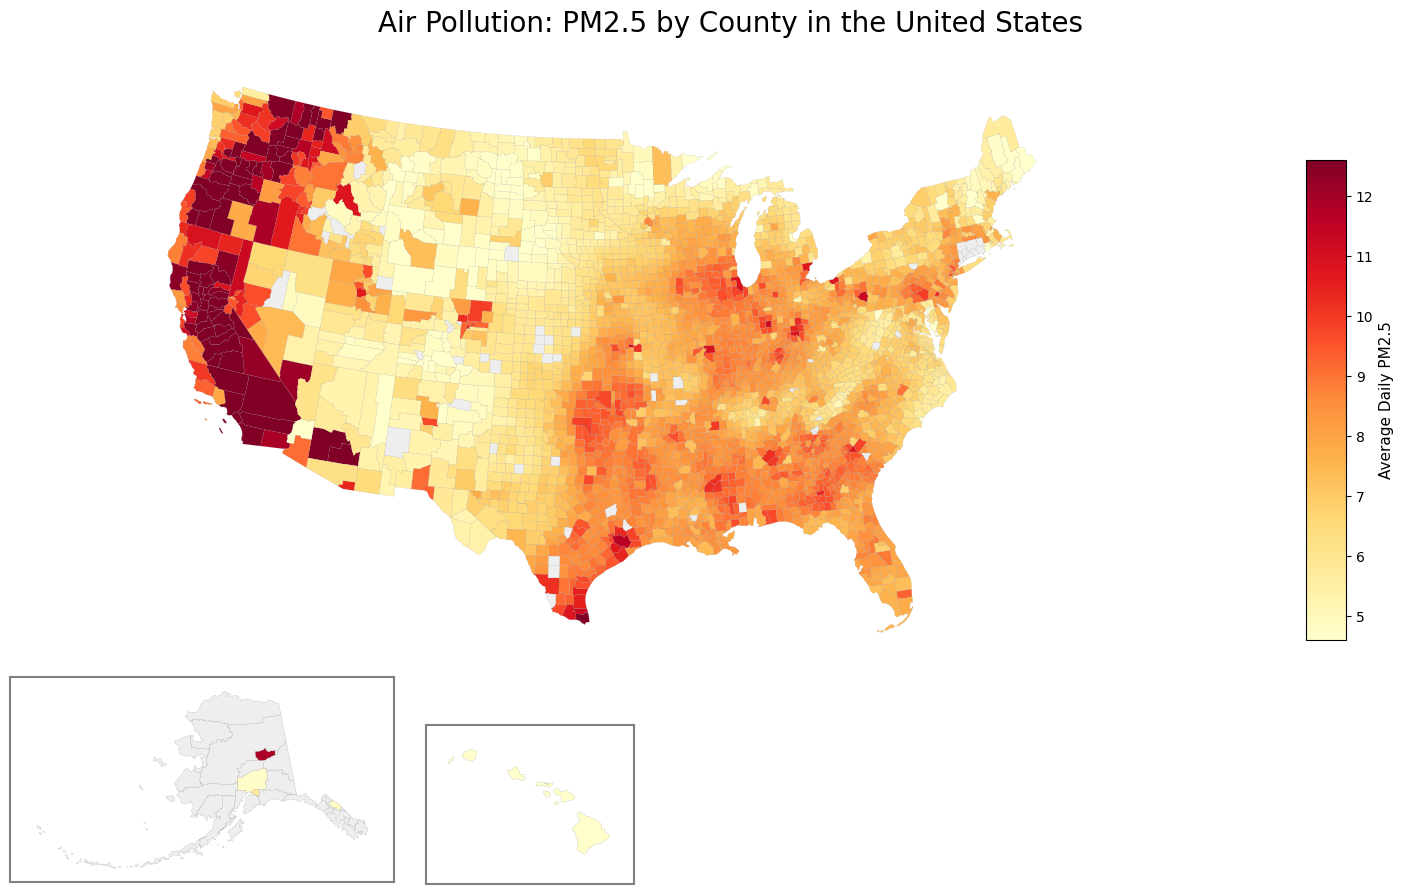

In [6]:
# Run once
# ! pip install numpy geopandas pandas matplotlib openpyxl

import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

file = "/content/2025 County Health Rankings Data - v4.xlsx"

# Load County Health Rankings data

excel_data = pd.read_excel(
    file,
    sheet_name="Select Measure Data",
    header=1
)

air_pollution = excel_data[[
    "FIPS",
    "State",
    "County",
    "Average Daily PM2.5"
]].copy()

# Keep county rows only, while not remove missing PM2.5 values
# This is important because Alaska has a lot of missing PM2.5 counties
air_pollution = air_pollution[air_pollution["County"].notna()].copy()

# Clean FIPS and PM2.5 column
air_pollution["FIPS"] = air_pollution["FIPS"].astype(int).astype(str).str.zfill(5)
air_pollution["Average Daily PM2.5"] = pd.to_numeric(
    air_pollution["Average Daily PM2.5"],
    errors="coerce"
)


# Load county shapefile

counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"
)

# Keep original latitude/longitude first
counties = counties.to_crs(epsg=4326)

# Merge county map with PM2.5 data

merged = counties.merge(
    air_pollution,
    left_on="GEOID",
    right_on="FIPS",
    how="left"
)


# Remove territories using Census STATEFP

# STATEFP codes:
# 02 = Alaska
# 15 = Hawaii
# 60 = American Samoa
# 66 = Guam
# 69 = Northern Mariana Islands
# 72 = Puerto Rico
# 78 = Virgin Islands

territory_codes = ["60", "66", "69", "72", "78"]

merged = merged[~merged["STATEFP"].isin(territory_codes)].copy()

# Split into maps
lower48 = merged[~merged["STATEFP"].isin(["02", "15"])].copy()
alaska = merged[merged["STATEFP"] == "02"].copy()
hawaii = merged[merged["STATEFP"] == "15"].copy()

# Color
pm_values = merged["Average Daily PM2.5"].dropna()

vmin = pm_values.quantile(0.02)
vmax = pm_values.quantile(0.98)


# Lower 48 projection
lower48_proj = lower48.to_crs(epsg=5070)

# Alaska projection
alaska_proj = alaska.to_crs(epsg=3338)

# Hawaii is fine in latitude/longitude
hawaii_proj = hawaii.to_crs(epsg=4326)

# Figure layout

fig = plt.figure(figsize=(16, 10))


# Main Lower 48 map

ax_main = fig.add_axes([0.03, 0.30, 0.78, 0.60])

lower48_proj.plot(
    column="Average Daily PM2.5",
    cmap="YlOrRd",
    legend=False,
    edgecolor="gray",
    linewidth=0.08,
    vmin=vmin,
    vmax=vmax,
    ax=ax_main,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "gray",
        "linewidth": 0.08
    }
)

ax_main.axis("off")

# Alaska inset box

ax_ak = fig.add_axes([0.05, 0.07, 0.24, 0.22])
ax_ak.set_facecolor("white")

alaska_proj.plot(
    column="Average Daily PM2.5",
    cmap="YlOrRd",
    legend=False,
    edgecolor="gray",
    linewidth=0.12,
    vmin=vmin,
    vmax=vmax,
    ax=ax_ak,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "gray",
        "linewidth": 0.12
    }
)

# Alaska fill
minx, miny, maxx, maxy = alaska_proj.total_bounds
x_buffer = (maxx - minx) * 0.08
y_buffer = (maxy - miny) * 0.08

ax_ak.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_ak.set_ylim(miny - y_buffer, maxy + y_buffer)

# Box border
for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_edgecolor("gray")

ax_ak.set_xticks([])
ax_ak.set_yticks([])


# Hawaii inset box

ax_hi = fig.add_axes([0.31, 0.07, 0.13, 0.17])
ax_hi.set_facecolor("white")

hawaii_proj.plot(
    column="Average Daily PM2.5",
    cmap="YlOrRd",
    legend=False,
    edgecolor="gray",
    linewidth=0.12,
    vmin=vmin,
    vmax=vmax,
    ax=ax_hi,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "gray",
        "linewidth": 0.12
    }
)

ax_hi.set_xlim(-161, -154)
ax_hi.set_ylim(18, 23)

# Box border
for spine in ax_hi.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_edgecolor("gray")

ax_hi.set_xticks([])
ax_hi.set_yticks([])


# Colorbar
ax_cbar = fig.add_axes([0.86, 0.32, 0.025, 0.48])

sm = plt.cm.ScalarMappable(
    cmap="YlOrRd",
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)

sm._A = []

cbar = fig.colorbar(sm, cax=ax_cbar)
cbar.set_label("Average Daily PM2.5", fontsize=11)

# Title
fig.suptitle(
    "Air Pollution: PM2.5 by County in the United States",
    fontsize=20,
    y=0.95
)

plt.show()